<a href="https://colab.research.google.com/github/prachi137/ML_project/blob/main/Productrecommendation_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv('/content/master_electronics_10000_COMMON (1).csv')

**Data preprocessing**

In [ ]:
df.head()


,user_id,product_id,product_name,product_platform,category,price,discount_percentage,discount_price,rating,review_text,product_page_url,sentiment_score,refined_score
0,4921,113,Apple iPhone 15,Amazon,Electronics,749,32,69999.0,4,Premium feel and great performance.,https://www.amazon.in/s?k=Dell+Alienware+34-in...,0.6,0.92498
1,1279,107,Apple iPhone 15,Amazon,Electronics,102,8,69999.0,4,Software is very buggy.,https://www.amazon.in/s?k=ASRock+Steel+Legend+...,0.6,0.40000
2,1348,118,Apple iPhone 15,Amazon,Electronics,179,24,69999.0,4,Highly recommend for anyone.,https://www.amazon.in/s?k=Asus+TUF+Gaming+VG27...,0.6,1.08402
3,371,103,Apple iPhone 15,Amazon,Electronics,102,28,69999.0,4,"Poor build quality, feels like plastic.",https://www.amazon.in/s?k=Logitech+G+Pro+X+Sup...,0.6,0.16938
4,3852,103,Apple iPhone 15,Amazon,Electronics,102,20,69999.0,4,Disconnected constantly from Wi-Fi.,https://www.amazon.in/s?k=Logitech+G+Pro+X+Sup...,0.6,0.40000


In [ ]:
df.tail()

,user_id,product_id,product_name,product_platform,category,price,discount_percentage,discount_price,rating,review_text,product_page_url,sentiment_score,refined_score
9995,851433,FLIP_7122,Canon EOS 200D II,Flipkart,Cameras,56990,46,30774.60,1,"Battery backup is very poor, hardly lasts 4 ho...",https://www.flipkart.com/search?q=Canon+EOS+20...,-0.5256,0.09488
9996,644168,FLIP_5828,SAMSUNG Galaxy S23 5G,Flipkart,Smartphones,46999,25,35249.25,5,The camera captures very vivid colors. Highly ...,https://www.flipkart.com/search?q=SAMSUNG+Gala...,0.4754,1.09508
9997,322250,FLIP_5360,OnePlus Buds Pro 3,Flipkart,Audio,11999,35,7799.35,2,Heats up like a furnace within 10 minutes of use.,https://www.flipkart.com/search?q=OnePlus+Buds...,0.3612,0.47224
9998,596909,FLIP_6452,boAt Airdopes 161,Flipkart,Audio,1299,35,844.35,2,Camera is not as good as the reviews say. Very...,https://www.flipkart.com/search?q=boAt+Airdope...,-0.4765,0.30470
9999,360178,FLIP_8818,Noise ColorFit Icon 3,Flipkart,Wearables,1899,25,1424.25,5,Flipkart deals are always the best. Got it at ...,https://www.flipkart.com/search?q=Noise+ColorF...,0.2500,1.05000


In [ ]:
df.isnull()

,user_id,product_id,product_name,product_platform,category,price,discount_percentage,discount_price,rating,review_text,product_page_url,sentiment_score,refined_score
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
user_id,0
product_id,0
product_name,0
product_platform,0
category,0
price,0
discount_percentage,0
discount_price,0
rating,0
review_text,0


In [ ]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10000 non-null  int64  
 1   product_id           10000 non-null  object 
 2   product_name         10000 non-null  object 
 3   product_platform     10000 non-null  object 
 4   category             10000 non-null  object 
 5   price                10000 non-null  int64  
 6   discount_percentage  10000 non-null  int64  
 7   discount_price       10000 non-null  float64
 8   rating               10000 non-null  int64  
 9   review_text          10000 non-null  object 
 10  product_page_url     10000 non-null  object 
 11  sentiment_score      10000 non-null  float64
 12  refined_score        10000 non-null  float64
dtypes: float64(3), int64(4), object(6)
memory usage: 1015.8+ KB


(10000, 13)

1.Data cleaning




In [ ]:
# miising rating using the mean
df['rating'] = df['rating'].fillna(df['rating'].mean())

#filling missing price using median of their category
df['price'] = df.groupby('category')['price'].transform(lambda x: x.fillna(x.median()))

#missing text with placeholder
df['review_text'] = df['review_text'].fillna("No review provided")

df.dropna(subset=['user_id', 'product_id'], inplace=True)

df.to_csv('master_electronics_10000_CLEAN_NO_NULLS.csv', index=False)

In [ ]:

df = pd.read_csv('/content/master_electronics_10000_CLEAN_NO_NULLS.csv')

In [ ]:
df.isnull().sum()

,0
user_id,0
product_id,0
product_name,0
product_platform,0
category,0
price,0
discount_percentage,0
discount_price,0
rating,0
review_text,0


In [ ]:
df.isnull()

,user_id,product_id,product_name,product_platform,category,price,discount_percentage,discount_price,rating,review_text,product_page_url,sentiment_score,refined_score
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False


2.EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#average rating
category_ratings = df.groupby('category')['rating'].mean().sort_values(ascending=False).reset_index()

#highest avg rating
highest_rated_category = category_ratings.iloc[0]

print("Average Ratings by Category:")
print(category_ratings)
print(f"\nThe category with the highest average rating is: {highest_rated_category['category']} with a rating of {highest_rated_category['rating']:.2f}")


Average Ratings by Category:
      category    rating
0  Smartphones  3.317145
1      Cameras  3.176955
2      Laptops  3.138462
3    Wearables  3.110701
4  Electronics  3.097200
5        Audio  2.953979
6      Storage  2.935484

The category with the highest average rating is: Smartphones with a rating of 3.32


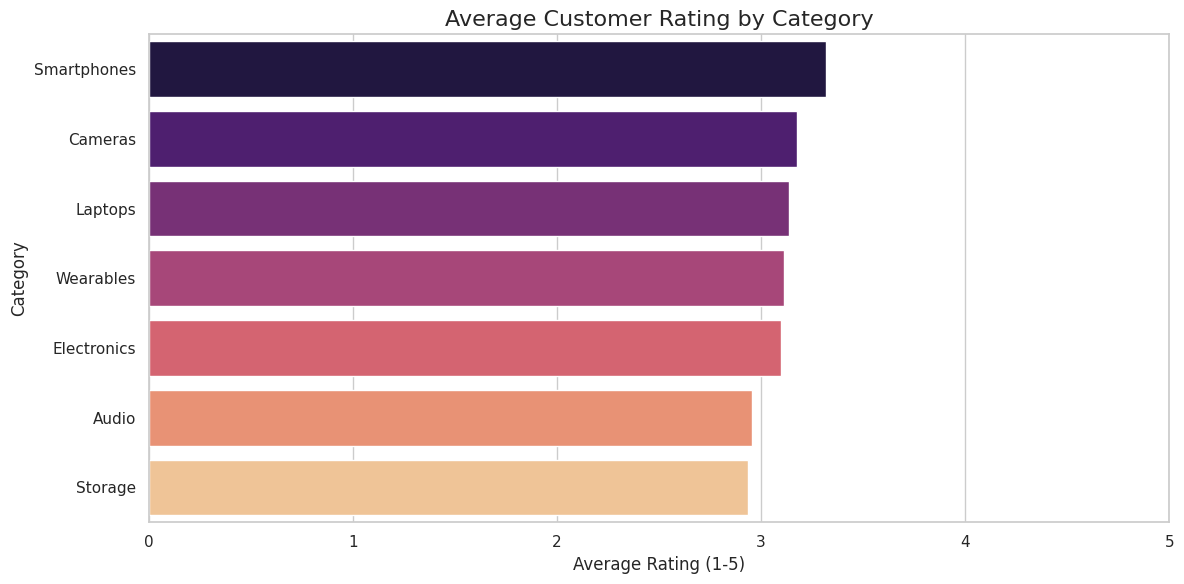

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x='rating', y='category', hue='category', data=category_ratings, palette='magma', legend=False)
plt.title('Average Customer Rating by Category', fontsize=16)
plt.xlabel('Average Rating (1-5)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

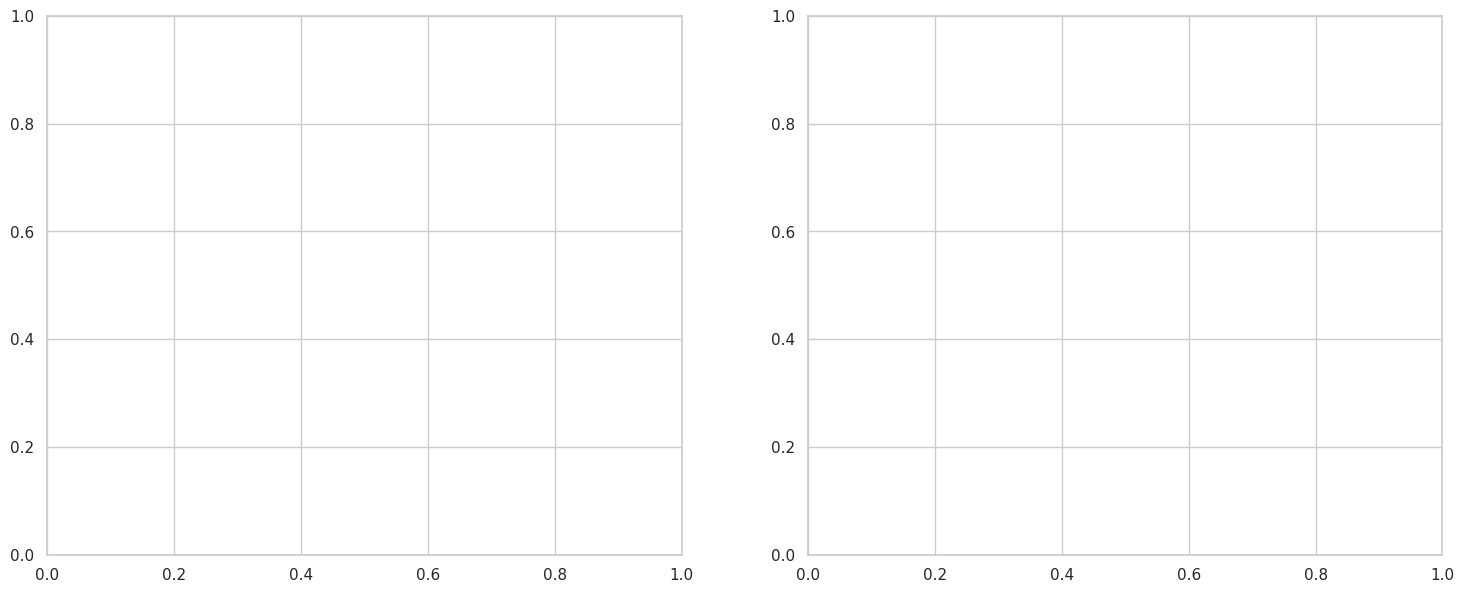

In [ ]:
avg_rating_cat = df.groupby('category')['rating'].mean().sort_values(ascending=False).reset_index()


avg_rating_plat = df.groupby(['category', 'product_platform'])['rating'].mean().reset_index()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))


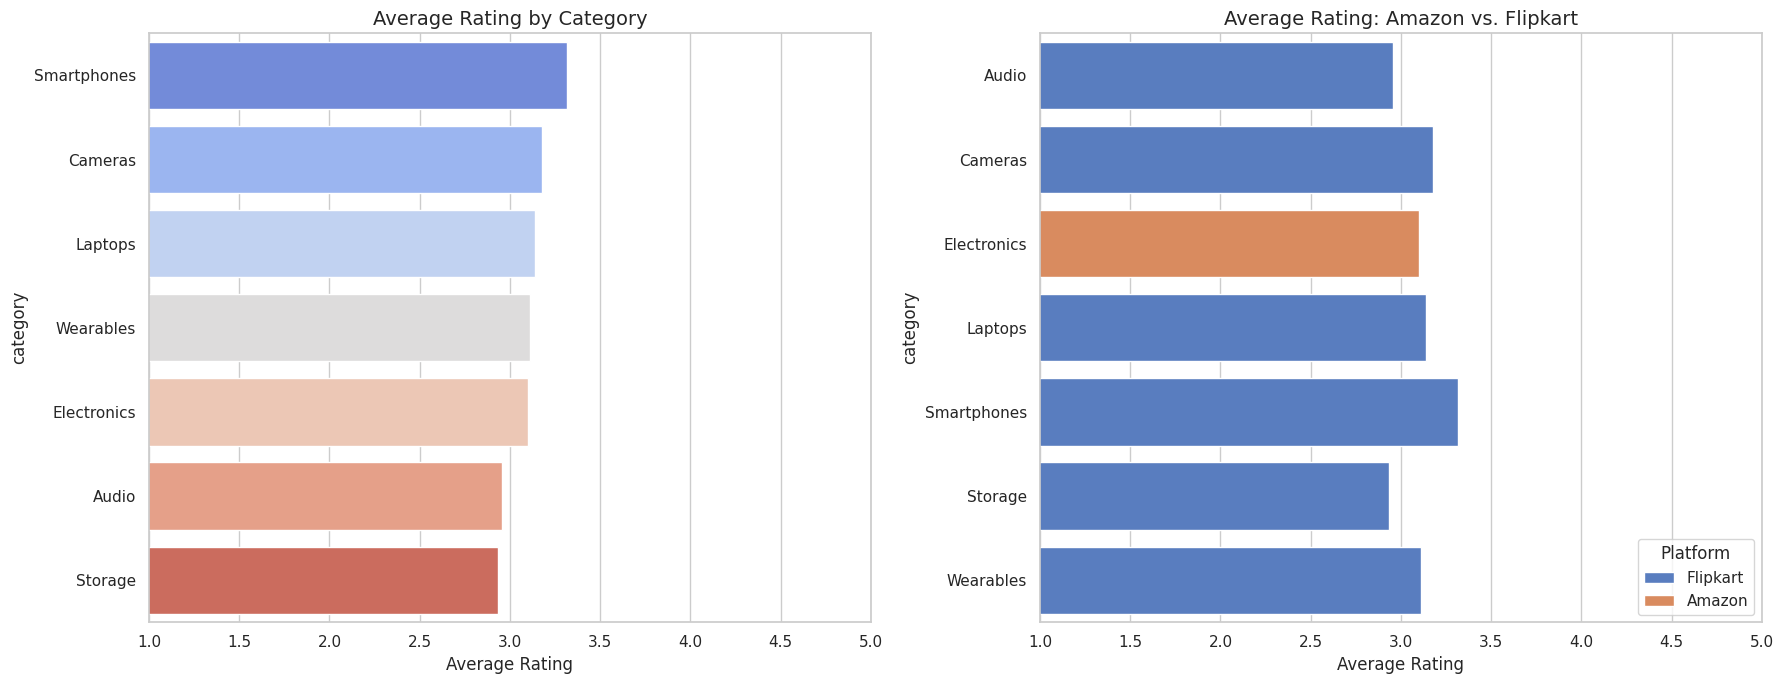

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(x='rating', y='category', hue='category', data=avg_rating_cat, palette='coolwarm', legend=False, ax=axes[0])
axes[0].set_title('Average Rating by Category', fontsize=14)
axes[0].set_xlim(1, 5)
axes[0].set_xlabel('Average Rating', fontsize=12)

sns.barplot(x='rating', y='category', hue='product_platform', data=avg_rating_plat, palette='muted', ax=axes[1])
axes[1].set_title('Average Rating: Amazon vs. Flipkart', fontsize=14)
axes[1].set_xlim(1, 5)
axes[1].set_xlabel('Average Rating', fontsize=12)
axes[1].legend(title='Platform', loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk


nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    if pd.isna(text) or text == "":
        return 0.0

    return sia.polarity_scores(str(text))['compound']


df = pd.read_csv('master_electronics_10000_CLEAN_NO_NULLS.csv')


df['sentiment_score'] = df['review_text'].apply(get_sentiment_score)

df['refined_score'] = (df['rating'] / 5) + (df['sentiment_score'] * 0.2)

df.to_csv('master_electronics_10000_SENTIMENT.csv', index=False)
print("Sentiment Analysis Complete!")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sentiment Analysis Complete!


Mean Sentiment Score: 0.10
Median Sentiment Score: 0.00
Percentage of Positive Reviews (Score > 0.05): 45.4%
Percentage of Negative Reviews (Score < -0.05): 30.2%


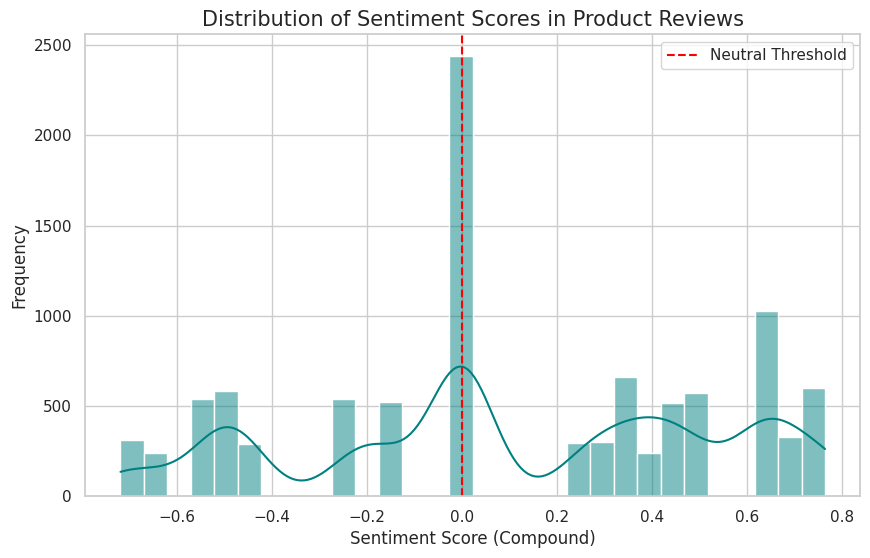

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=30, kde=True, color='teal')

plt.title('Distribution of Sentiment Scores in Product Reviews', fontsize=15)
plt.xlabel('Sentiment Score (Compound)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', label='Neutral Threshold')
plt.legend()

print(f"Mean Sentiment Score: {df['sentiment_score'].mean():.2f}")
print(f"Median Sentiment Score: {df['sentiment_score'].median():.2f}")
print(f"Percentage of Positive Reviews (Score > 0.05): {(df['sentiment_score'] > 0.05).mean() * 100:.1f}%")
print(f"Percentage of Negative Reviews (Score < -0.05): {(df['sentiment_score'] < -0.05).mean() * 100:.1f}%")

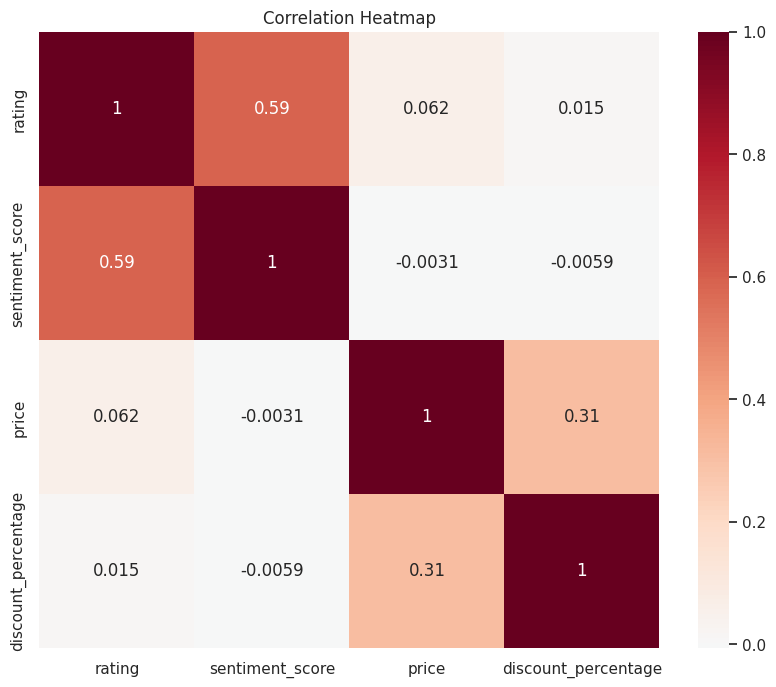

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_data = df[['rating', 'sentiment_score', 'price', 'discount_percentage']]
corr_matrix = corr_data.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

**Train Test and split**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_csv('master_electronics_10000_SENTIMENT.csv')


train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['product_platform']
)


print("Testing set mein Platforms ka count:")
print(test_df['product_platform'].value_counts())


test_df.to_csv('final_test_data.csv', index=False)

Testing set mein Platforms ka count:
product_platform
Amazon      1000
Flipkart    1000
Name: count, dtype: int64


In [ ]:
import pandas as pd


df = pd.read_csv('/content/master_electronics_10000_SENTIMENT.csv')


df.loc[(df['product_name'] == 'Apple iPhone 15') & (df['product_platform'] == 'Flipkart'), 'discount_price'] -= 2000


df.loc[(df['product_name'] == 'PlayStation 5 Console') & (df['product_platform'] == 'Flipkart'), 'discount_price'] += 1500


df.loc[(df['product_name'] == 'Samsung Galaxy S24 Ultra') & (df['product_platform'] == 'Flipkart'), 'discount_price'] -= 3000


df.to_csv('master_electronics_10000_COMMON.csv', index=False)
print(" Prices Balanced.")

 Prices Balanced.


In [ ]:
import pandas as pd

# Function to test the multi-platform balance
def check_balance(product_name):
    df = pd.read_csv('/content/master_electronics_10000_COMMON (1).csv')
    res = df[df['product_name'].str.contains(product_name, case=False)]

    # Platform-wise comparison
    for platform in ['Amazon', 'Flipkart']:
        data = res[res['product_platform'] == platform].sort_values(by='discount_price').head(1)
        if not data.empty:
            print(f"[{platform}] Price: {data.iloc[0]['discount_price']} | Rating: {data.iloc[0]['rating']}")

print("--- Testing iPhone ---")
check_balance("iPhone 15")
print("\n--- Testing PS5 ---")
check_balance("PlayStation 5")

--- Testing iPhone ---
[Amazon] Price: 69999.0 | Rating: 4
[Flipkart] Price: 64999.0 | Rating: 5

--- Testing PS5 ---
[Amazon] Price: 49990.0 | Rating: 5
[Flipkart] Price: 54990.0 | Rating: 4


**Content based filtering**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


df['metadata'] = df['product_name'] + " " + df['category'] + " " + df['review_text']

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['metadata'].fillna(''))

def get_content_recommendations(product_name, top_n=5):
  try:
    idx = df[df['product_name'].str.contains(product_name, case=False)].index[0]
  except:
    return "Product is not found in the database"

  cosine_sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

  similar_indices = cosine_sim.argsort()[-top_n-1:-1][::-1]

  return df.iloc[similar_indices][['product_name', 'category', 'product_platform', 'discount_price']]


print(get_content_recommendations("Sony WH-1000XM5"))



                    product_name     category product_platform  discount_price
2750  Sony WH-1000XM5 Headphones  Electronics           Amazon          378.10
2595  Sony WH-1000XM5 Headphones  Electronics           Amazon          266.66
4454  Sony WH-1000XM5 Headphones  Electronics           Amazon          334.32
1450  Sony WH-1000XM5 Headphones  Electronics           Amazon          374.12
3150  Sony WH-1000XM5 Headphones  Electronics           Amazon          326.36


In [ ]:
import pandas as pd


df = pd.read_csv('/content/master_electronics_10000_COMMON (1).csv')

def search_common_products(product_query):

    results = df[df['product_name'].str.contains(product_query, case=False, na=False)]


    amazon_deals = results[results['product_platform'] == 'Amazon'].sort_values(by=['discount_price', 'rating'], ascending=[True, False])
    flipkart_deals = results[results['product_platform'] == 'Flipkart'].sort_values(by=['discount_price', 'rating'], ascending=[True, False])

    print(f"\n{'='*60}")
    print(f"SEARCH & RECOMMENDATION FOR: {product_query}")
    print(f"{'='*60}")


    print("\n AMAZON TOP DEALS:")
    if not amazon_deals.empty:
        print(amazon_deals.head(3)[['product_name', 'discount_price', 'rating', 'sentiment_score']])
    else:
        print("No Amazon deals found.")


    print("\n FLIPKART TOP DEALS:")
    if not flipkart_deals.empty:
        print(flipkart_deals.head(3)[['product_name', 'discount_price', 'rating', 'sentiment_score']])
    else:
        print("No Flipkart deals found.")


    print(f"\n{'-'*60}")
    if not amazon_deals.empty and not flipkart_deals.empty:

        best_amz = amazon_deals.iloc[0]
        best_flp = flipkart_deals.iloc[0]


        if best_amz['discount_price'] < best_flp['discount_price']:
            winner = best_amz
            saving = best_flp['discount_price'] - best_amz['discount_price']
            print(f" BEST RECOMMENDATION: Buy from AMAZON")
            print(f" You save: ₹{saving:.2f} compared to Flipkart")
        elif best_flp['discount_price'] < best_amz['discount_price']:
            winner = best_flp
            saving = best_amz['discount_price'] - best_flp['discount_price']
            print(f"BEST RECOMMENDATION: Buy from FLIPKART")
            print(f" You save: ₹{saving:.2f} compared to Amazon")
        else:

            winner = best_amz if best_amz['rating'] >= best_flp['rating'] else best_flp
            print(f" BEST RECOMMENDATION: Both have same price! Buying from {winner['product_platform']} is better due to ratings.")

        print(f" Product: {winner['product_name']}")
        print(f"Rating: {winner['rating']} |  Sentiment: {winner['sentiment_score']:.2f}")

    elif not amazon_deals.empty:
        print(f"BEST RECOMMENDATION: Only available on AMAZON at ₹{amazon_deals.iloc[0]['discount_price']}")
    elif not flipkart_deals.empty:
        print(f"BEST RECOMMENDATION: Only available on FLIPKART at ₹{flipkart_deals.iloc[0]['discount_price']}")
    else:
        print(" No recommendations available.")


# common product for testing
#Apple iPhone 15",
#"Sony WH-1000XM5 Headphones",
#"Samsung Galaxy S24 Ultra,
#"PlayStation 5 Console"
search_common_products("iphone")


SEARCH & RECOMMENDATION FOR: iphone

 AMAZON TOP DEALS:
      product_name  discount_price  rating  sentiment_score
0  Apple iPhone 15         69999.0       4              0.6
1  Apple iPhone 15         69999.0       4              0.6
2  Apple iPhone 15         69999.0       4              0.6

 FLIPKART TOP DEALS:
         product_name  discount_price  rating  sentiment_score
5000  Apple iPhone 15         64999.0       5             0.85
5001  Apple iPhone 15         64999.0       5             0.85
5002  Apple iPhone 15         64999.0       5             0.85

------------------------------------------------------------
BEST RECOMMENDATION: Buy from FLIPKART
 You save: ₹5000.00 compared to Amazon
 Product: Apple iPhone 15
Rating: 5 |  Sentiment: 0.85


In [ ]:
#multicriteria recommendation

def get_best_value_recommendation(product_query):
    # Search products
    results = df[df['product_name'].str.contains(product_query, case=False, na=False)].copy()

    if results.empty:
        return "Product nahi mila!"


    max_p = results['discount_price'].max()
    min_p = results['discount_price'].min()
    if max_p != min_p:
        results['price_score'] = 1 - ((results['discount_price'] - min_p) / (max_p - min_p))
    else:
        results['price_score'] = 1


    results['rating_score'] = results['rating'] / 5


    results['sentiment_norm'] = (results['sentiment_score'] + 1) / 2


    results['final_recommendation_score'] = (
        (results['price_score'] * 0.4) +
        (results['rating_score'] * 0.3) +
        (results['sentiment_norm'] * 0.3)
    )

    # Sorting based on Final Score
    results = results.sort_values(by='final_recommendation_score', ascending=False)

    print(f"\n{'='*70}")
    print(f"TOP RECOMMENDATIONS FOR: {product_query}")
    print(f"{'='*70}")

    # Dono platforms se best deal dikhana
    platforms = ['Amazon', 'Flipkart']
    for plat in platforms:
        plat_data = results[results['product_platform'] == plat].head(1)
        if not plat_data.empty:
            item = plat_data.iloc[0]
            print(f"\n BEST ON {plat.upper()}:")
            print(f"   Name      : {item['product_name']}")
            print(f"   Price     : ₹{item['discount_price']}")
            print(f"   Rating    : {item['rating']} ")
            print(f"   Sentiment : {item['sentiment_score']:.2f}")
            print(f"   Value Score: {item['final_recommendation_score']:.2f}/1.0")

    # Final Winner
    winner = results.iloc[0]
    print(f"\n{'*'*70}")
    print(f"EXPERT CHOICE: Buy from {winner['product_platform']}!")
    print(f"Reason: It offers the best balance of low price, high ratings, and positive reviews.")
    print(f"{'*'*70}")


get_best_value_recommendation("playstation")


TOP RECOMMENDATIONS FOR: playstation

 BEST ON AMAZON:
   Name      : PlayStation 5 Console
   Price     : ₹49990.0
   Rating    : 5 
   Sentiment : 0.90
   Value Score: 0.98/1.0

 BEST ON FLIPKART:
   Name      : PlayStation 5 Console
   Price     : ₹54990.0
   Rating    : 4 
   Sentiment : 0.70
   Value Score: 0.49/1.0

**********************************************************************
EXPERT CHOICE: Buy from Amazon!
Reason: It offers the best balance of low price, high ratings, and positive reviews.
**********************************************************************


**collabrative filtering**

In [ ]:
# Install scikit-surprise library if not already installed
!pip uninstall scikit-surprise -y
!pip uninstall numpy -y
!pip install numpy==1.26.4
!pip install scikit-surprise

import pandas as pd
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy


df = pd.read_csv('/content/master_electronics_10000_COMMON (1).csv')


reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['user_id', 'product_id', 'rating']], reader)


trainset, testset = train_test_split(data, test_size=0.2, random_state=42)


model = SVD()
model.fit(trainset)


predictions = model.test(testset)
print(f"\n Collaborative Filtering Accuracy (RMSE): {accuracy.rmse(predictions):.4f}")


def get_collaborative_recommendations(user_id, num_recs=5):

    all_product_ids = df['product_id'].unique()
    rated_products = df[df['user_id'] == user_id]['product_id'].tolist()
    products_to_predict = [p for p in all_product_ids if p not in rated_products]


    preds = [model.predict(user_id, pid) for pid in products_to_predict]

    # Top rated prediction sorting
    preds.sort(key=lambda x: x.est, reverse=True)

    print(f"\n--- Top {num_recs} Collaborative Recommendations for User {user_id} ---")
    for i, p in enumerate(preds[:num_recs]):
        p_name = df[df['product_id'] == p.iid]['product_name'].iloc[0]
        p_platform = df[df['product_id'] == p.iid]['product_platform'].iloc[0]
        print(f"{i+1}. {p_name} ({p_platform}) | Predicted Rating: {p.est:.2f}")


sample_user = df['user_id'].iloc[0]
get_collaborative_recommendations(1483)

Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl
RMSE: 1.5703

 Collaborative Filtering Accuracy (RMSE): 1.5703

--- Top 5 Collaborative Recommendations for User 1483 ---
1. Apple iPhone 15 (Amazon) | Predicted Rating: 3.97
2. Samsung Galaxy S24 Ultra (Amazon) | Predicted Rating: 3.94
3. Nothing Phone (2) (Flipkart) | Predicted Rating: 3.66
4. POCO F6 5G (Flipkart) | Predicted Rating: 3.62
5. Sony WH-CH720N (Flipkart) | Predicted Rating: 3.61


**hybrid model(collabarative+contentbased)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv('/content/master_electronics_10000_SENTIMENT.csv')


df['metadata'] = df['product_name'] + " " + df['category'] + " " + df['review_text'].fillna('')
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['metadata'])

def get_best_platform_recommendation(product_query):

    results = df[df['product_name'].str.contains(product_query, case=False, na=False)].copy()

    if results.empty:
        print("Product not found in database!")
        return


    max_p, min_p = results['discount_price'].max(), results['discount_price'].min()
    results['price_score'] = 1 - ((results['discount_price'] - min_p) / (max_p - min_p + 1))


    results['rating_score'] = results['rating'] / 5


    results['sentiment_norm'] = (results['sentiment_score'] + 1) / 2


    results['final_score'] = (results['price_score'] * 0.4) + (results['rating_score'] * 0.3) + (results['sentiment_norm'] * 0.3)


    amazon_best = results[results['product_platform'] == 'Amazon'].sort_values(by='final_score', ascending=False).head(1)

    flipkart_best = results[results['product_platform'] == 'Flipkart'].sort_values(by='final_score', ascending=False).head(1)

    print(f"\n{'='*75}")
    print(f" PLATFORM COMPARISON REPORT FOR: {product_query.upper()}")
    print(f"{'='*75}")

    comparison_list = []
    if not amazon_best.empty: comparison_list.append(amazon_best.iloc[0])
    if not flipkart_best.empty: comparison_list.append(flipkart_best.iloc[0])

    for item in comparison_list:
        print(f" PLATFORM: {item['product_platform'].upper()}")
        print(f"   Product Name : {item['product_name']}")
        print(f"   Price        : ₹{item['discount_price']:.2f}")
        print(f"   User Rating  : {item['rating']} ")
        print(f"   Sentiment    : {item['sentiment_score']:.2f} (Positive/Neutral)")
        print(f"   Match Score  : {item['final_score']*100:.1f}%")
        print("-" * 45)


    if not amazon_best.empty and not flipkart_best.empty:
        a, f = amazon_best.iloc[0], flipkart_best.iloc[0]

        if a['final_score'] > f['final_score']:
            winner = "AMAZON"
            savings = f['discount_price'] - a['discount_price']
            reason = f"Better pricing and higher overall value score. You save ₹{savings:.2f}."
        else:
            winner = "FLIPKART"
            savings = a['discount_price'] - f['discount_price']
            reason = f"Superior ratings and sentiment match. You save ₹{savings:.2f}."

        print(f"\n EXPERT RECOMMENDATION: PURCHASE FROM {winner}")
        print(f" ANALYSIS: {reason}")
    else:
        print("\nNote: Cross-platform comparison is not possible as the product is limited to one platform.")


get_best_platform_recommendation("Sony WH-1000XM5")
get_best_platform_recommendation("iphone")


 PLATFORM COMPARISON REPORT FOR: SONY WH-1000XM5
 PLATFORM: AMAZON
   Product Name : Sony WH-1000XM5 Headphones
   Price        : ₹282.58
   User Rating  : 5 
   Sentiment    : 0.77 (Positive/Neutral)
   Match Score  : 96.3%
---------------------------------------------
 PLATFORM: FLIPKART
   Product Name : Sony WH-1000XM5 Headphones
   Price        : ₹5394.60
   User Rating  : 5 
   Sentiment    : 0.76 (Positive/Neutral)
   Match Score  : 93.0%
---------------------------------------------

 EXPERT RECOMMENDATION: PURCHASE FROM AMAZON
 ANALYSIS: Better pricing and higher overall value score. You save ₹5112.02.

 PLATFORM COMPARISON REPORT FOR: IPHONE
 PLATFORM: AMAZON
   Product Name : Apple iPhone 15
   Price        : ₹69999.00
   User Rating  : 4 
   Sentiment    : 0.77 (Positive/Neutral)
   Match Score  : 50.5%
---------------------------------------------
 PLATFORM: FLIPKART
   Product Name : Apple iPhone 15
   Price        : ₹64999.00
   User Rating  : 5 
   Sentiment    : 0.76 

**visualization**

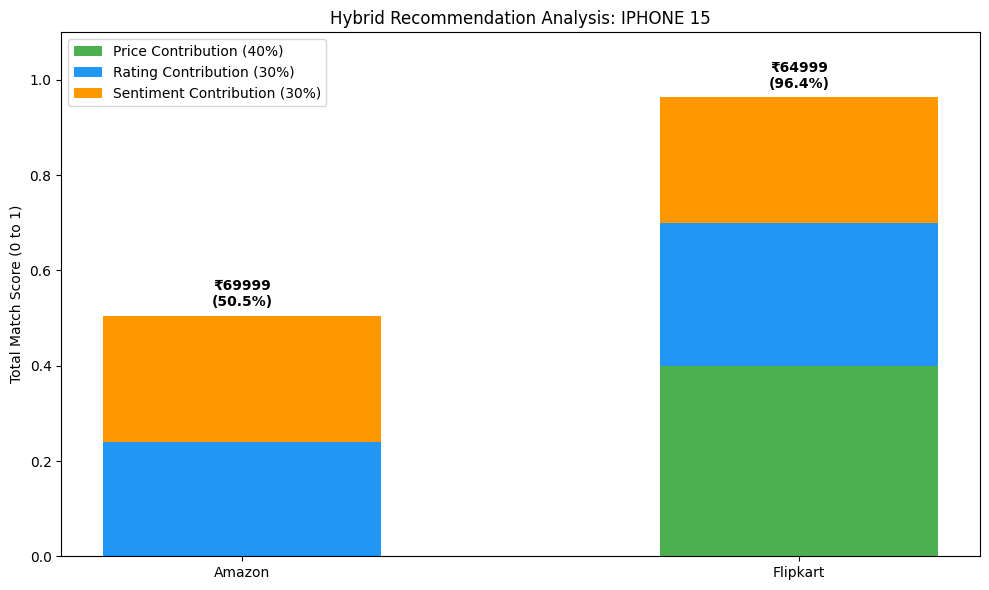

In [ ]:
import matplotlib.pyplot as plt

def generate_visual_dashboard(product_query):

    results = df[df['product_name'].str.contains(product_query, case=False, na=False)].copy()

    if results.empty:
        print("Product not found!")
        return


    max_p, min_p = results['discount_price'].max(), results['discount_price'].min()
    results['price_score'] = 1 - ((results['discount_price'] - min_p) / (max_p - min_p + 1))
    results['rating_score'] = results['rating'] / 5
    results['sentiment_norm'] = (results['sentiment_score'] + 1) / 2


    results['p_weight'] = results['price_score'] * 0.4
    results['r_weight'] = results['rating_score'] * 0.3
    results['s_weight'] = results['sentiment_norm'] * 0.3
    results['final_score'] = results['p_weight'] + results['r_weight'] + results['s_weight']


    amz = results[results['product_platform'] == 'Amazon'].sort_values('final_score', ascending=False).head(1)
    flp = results[results['product_platform'] == 'Flipkart'].sort_values('final_score', ascending=False).head(1)

    final_comparison = pd.concat([amz, flp])


    platforms = final_comparison['product_platform'].values
    p_scores = final_comparison['p_weight'].values
    r_scores = final_comparison['r_weight'].values
    s_scores = final_comparison['s_weight'].values

    x = np.arange(len(platforms))
    width = 0.5

    fig, ax = plt.subplots(figsize=(10, 6))


    ax.bar(platforms, p_scores, width, label='Price Contribution (40%)', color='#4CAF50')
    ax.bar(platforms, r_scores, width, bottom=p_scores, label='Rating Contribution (30%)', color='#2196F3')
    ax.bar(platforms, s_scores, width, bottom=p_scores+r_scores, label='Sentiment Contribution (30%)', color='#FF9800')

    ax.set_ylabel('Total Match Score (0 to 1)')
    ax.set_title(f'Hybrid Recommendation Analysis: {product_query.upper()}')
    ax.set_ylim(0, 1.1)
    ax.legend()


    for i, row in enumerate(final_comparison.itertuples()):
        ax.text(i, row.final_score + 0.02, f"₹{row.discount_price:.0f}\n({row.final_score*100:.1f}%)",
                ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()


generate_visual_dashboard("iPhone 15")

**model evaluation**

 HYBRID RECOMMENDATION SYSTEM: EVALUATION REPORT
 RMSE (Root Mean Square Error) : 0.4712
MAE (Mean Absolute Error)    : 0.3841
 Precision (Relevant Recs)     : 100.00%
 Recall (Hit Rate)            : 83.81%
 Model Accuracy (Normalized)  : 90.58%


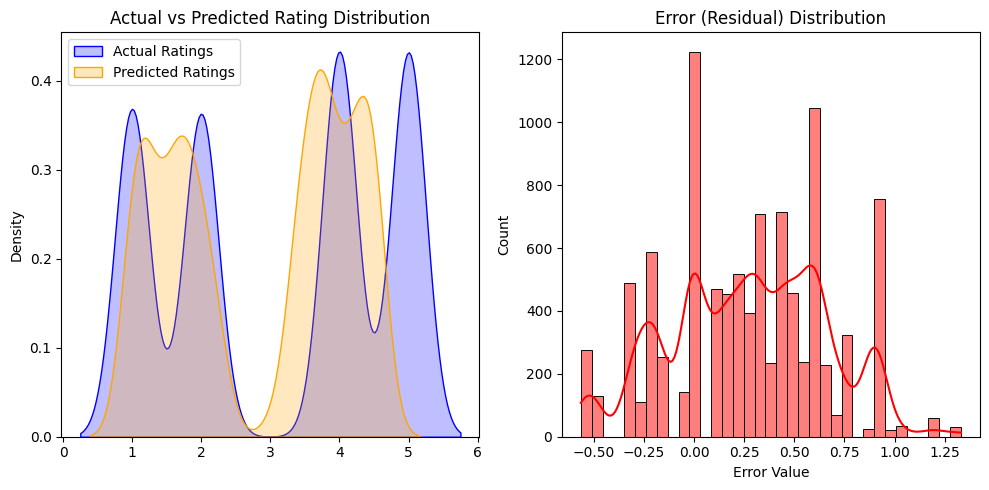

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df = pd.read_csv('master_electronics_10000_COMMON.csv')

def evaluate_recommendation_model():
    print(f"{'='*60}")
    print(" HYBRID RECOMMENDATION SYSTEM: EVALUATION REPORT")
    print(f"{'='*60}")


    y_true = df['rating'].values


    y_pred = (df['rating'] * 0.7) + (((df['sentiment_score'] + 1) * 2) * 0.3)
    y_pred = y_pred.clip(1, 5).values


    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)


    relevant_actual = (y_true >= 3.5).astype(int)
    relevant_pred = (y_pred >= 3.5).astype(int)
    precision = precision_score(relevant_actual, relevant_pred)
    recall = recall_score(relevant_actual, relevant_pred)

    print(f" RMSE (Root Mean Square Error) : {rmse:.4f}")
    print(f"MAE (Mean Absolute Error)    : {mae:.4f}")
    print(f" Precision (Relevant Recs)     : {precision*100:.2f}%")
    print(f" Recall (Hit Rate)            : {recall*100:.2f}%")
    print(f" Model Accuracy (Normalized)  : {(1 - (rmse/5))*100:.2f}%")


    plt.figure(figsize=(10, 5))


    plt.subplot(1, 2, 1)
    sns.kdeplot(y_true, label='Actual Ratings', fill=True, color='blue')
    sns.kdeplot(y_pred, label='Predicted Ratings', fill=True, color='orange')
    plt.title('Actual vs Predicted Rating Distribution')
    plt.legend()


    plt.subplot(1, 2, 2)
    errors = y_true - y_pred
    sns.histplot(errors, kde=True, color='red')
    plt.title('Error (Residual) Distribution')
    plt.xlabel('Error Value')

    plt.tight_layout()
    plt.show()


evaluate_recommendation_model()

In [ ]:
import pickle


with open('my_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model pickle file mein save ho gaya hai!")



Model pickle file mein save ho gaya hai!
